## surface term breakdown for ASTE 90, cleaned up version

In [1]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [2]:
import numpy as np
import sys
sys.path.append("/home/mmurakami/MITgcm/MITgcm_c68r/MITgcm-checkpoint68r/utils/python/MITgcmutils/MITgcmutils/") # go to parent dir
from mds import *
import os
sys.path.append("/home/mmurakami/crios_backups/an_helper_functions")
sys.path.append("/home/mmurakami/crios_backups/an_helper_functions")
from read_binary import *
from calc_UV_conv_1face import calc_UV_conv_1face
from calc_mskmean_T_mod import calc_mskmean_T_mod
from mk3D_mod import mk3D_mod
from aste_helper_funcs import *
from timing_functions import *           # ts2dte, get_fnames, etc.
from binning import *

In [3]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [4]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

In [5]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [6]:
# load the mask in 1D to get the points from offline

# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)
ind2d = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1
# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan
ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

# load the indices for layers
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

In [7]:
landmsk = np.zeros((ny,nx))
landmsk[np.isnan(mygrid['hFacC'][0])] = 1
land_dataf3 = get_aste_faces(landmsk,nfx,nfy).f3[0]
land_dataf3[land_dataf3==0]  = np.nan
landmsk[landmsk==0]= np.nan

## load the terms for the surface heat budget

In [8]:
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

In [9]:
# we need TFLUX from before
# to get the surface term, we need J/s and convert to degC.m^3/s
file_name = 'budg2d_zflux_set1'
meta_budg2d_zflux_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg2d_zflux_set1["fldList"])
print(fldlist)
varnames = np.array(["TFLUX","oceQsw","SItflux"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
TFLUX,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
oceQsw,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
SItflux,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[2])
TFLUX = TFLUX.reshape(ny,nx)
oceQsw = oceQsw.reshape(ny,nx)
SItflux = SItflux.reshape(ny,nx)  # + increase T

file_name = "budg2d_zflux_set2"
meta_budg2d_zflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg2d_zflux_set2["fldList"])
print(fldlist)

# terms to load
varnames = np.array(["oceQnet", "SIatmQnt", "SIsnPrcp", "SIacSubl", "SIaaflux"])

# find record index for each variable
recs = {}
for var in varnames:
    matches = np.where(fldlist == var)[0]
    if len(matches) == 0:
        raise ValueError(f"{var} not found in {file_name}")
    recs[var] = int(matches[0])

# load all requested fields
fields = {}
for var in varnames:
    arr, its, meta = rdmds(
        os.path.join(dirdiags, file_name),
        t2,
        returnmeta=True,
        rec=recs[var]
    )
    fields[var] = arr.reshape(ny, nx)

# unpack into named variables
oceQnet  = fields["oceQnet"]
SIatmQnt = fields["SIatmQnt"]
SIsnPrcp = fields["SIsnPrcp"]
SIacSubl = fields["SIacSubl"]
SIaaflux = fields["SIaaflux"]

# optional quick check
for var in varnames:
    print(var, fields[var].shape, np.nanmin(fields[var]), np.nanmax(fields[var]))

# we need to create zconv_top and swtop
dd = mygrid['RF'][:-1]
swfrac = 0.62*np.exp(dd/0.6)+(1-0.62)*np.exp(dd/20)
swfrac[dd < -200] = 0
swtop=mk3D_mod(swfrac,np.zeros((nz,ny,nx)))*mk3D_mod(RAC*oceQsw,np.zeros((nz,ny,nx)))   # J/s

# zconvtop_heat is here
zconv_top_heat = TFLUX * RAC     # W/m^2 * m^2 = J/s

['oceFWflx' 'SIatmFW' 'TFLUX' 'SItflux' 'SFLUX' 'oceQsw' 'oceSPflx']
['WTHMASS' 'WSLTMASS' 'oceSflux' 'oceQnet' 'SIatmQnt' 'SIaaflux'
 'SIsnPrcp' 'SIacSubl']
oceQnet (450, 90) -1089.3920417471434 250.64218703219382
SIatmQnt (450, 90) -250.64218703219382 788.6824373487643
SIsnPrcp (450, 90) -1.0718450542966325e-07 0.00018940653271159143
SIacSubl (450, 90) 0.0 1.0008364033143404e-05
SIaaflux (450, 90) -4.731989512409661 8.022287163889038


In [10]:
############################################################
# surface heat diagnostics in J/s
Q_total      = TFLUX * RAC                  # total surface heat input
Qsw_top      = oceQsw * RAC                 # shortwave entering through surface
QnonSW_top   = (TFLUX - oceQsw) * RAC       # non-shortwave surface heat input

swtop = (
    mk3D_mod(swfrac, np.zeros((nz, ny, nx))) *
    mk3D_mod(RAC * oceQsw, np.zeros((nz, ny, nx)))
)

############################################################
def surface_contrib_JT(zconv_top_heat, swtop, rcp, fill_last=0.0):
    """
    zconv_top_heat: (ny, nx)     surface convergence term in J/s
    swtop:          (nz, ny, nx) penetrating downward flux profile in J/s
    returns:
      JsurfT:       (nz, ny, nx) in degC.m^3/s
    """
    nz_, ny_, nx_ = swtop.shape
    eT = zconv_top_heat.reshape(1, ny_, nx_)
    J = np.empty_like(swtop, dtype=float)

    J[0] = (eT[0] - swtop[1]) / rcp
    J[1:nz_-1] = -(swtop[2:nz_] - swtop[1:nz_-1]) / rcp
    J[-1] = fill_last

    return J

############################################################
# original total surface contribution
Ft_surf = surface_contrib_JT(
    Q_total,
    swtop,
    myparms['rcp']
)

############################################################
# split into physically interpretable pieces

# 1) non-shortwave top-boundary contribution
Ft_nonSW_top = surface_contrib_JT(
    QnonSW_top,
    np.zeros((nz, ny, nx)),
    myparms['rcp']
)

# 2) shortwave top-boundary entry only
Ft_Qsw_top = surface_contrib_JT(
    Qsw_top,
    np.zeros((nz, ny, nx)),
    myparms['rcp']
)

# 3) shortwave redistribution by penetration
Ft_swredistrib = surface_contrib_JT(
    np.zeros((ny, nx)),
    swtop,
    myparms['rcp']
)

# optional combined shortwave term
Ft_shortwave = Ft_Qsw_top + Ft_swredistrib

############################################################
# closure checks
print("max abs error, 3-term closure:",
      np.nanmax(np.abs(Ft_surf - (Ft_nonSW_top + Ft_Qsw_top + Ft_swredistrib))))

print("max abs error, 2-term closure:",
      np.nanmax(np.abs(Ft_surf - (Ft_nonSW_top + Ft_shortwave))))

############################################################
# mapping return: surface terms
termsT3D = {}
termsT3D["TFLUX"]         = Ft_surf
termsT3D["nonSW_top"]     = Ft_nonSW_top
termsT3D["Qsw_top"]       = Ft_Qsw_top
termsT3D["swredistrib"]   = Ft_swredistrib
termsT3D["shortwave"]     = Ft_shortwave

############################################################
# binning: surface terms
term_names = [
    "TFLUX",
    "nonSW_top",
    "Qsw_top",
    "swredistrib",
    "shortwave",
]

term_fields = {
    "TFLUX":       Ft_surf,
    "nonSW_top":   Ft_nonSW_top,
    "Qsw_top":     Ft_Qsw_top,
    "swredistrib": Ft_swredistrib,
    "shortwave":   Ft_shortwave,
}

nterms = len(term_names)
dF_Tnew = np.zeros((nterms, nT - 1))
G_T_offline_new = np.zeros((nterms, nT - 1))
Lijnew = np.zeros((1, nT - 1), dtype=int)

T_flat = np.ravel(THETA * mymsk3d, order='F')
term_flats = {
    name: np.ravel(field * mymsk3d, order='F')
    for name, field in term_fields.items()
}

for i in range(nT - 1):
    ij = np.where((T_flat >= binmidT[i]) & (T_flat < binmidT[i + 1]))[0]
    Lijnew[0, i] = len(ij)

    if len(ij) > 0:
        for it, name in enumerate(term_names):
            dF_Tnew[it, i] = np.nansum(term_flats[name][ij])

G_T_offline_new = dF_Tnew / binwidthT1[None, :]

dF_T_dict = {name: dF_Tnew[it] for it, name in enumerate(term_names)}
G_T_dict  = {name: G_T_offline_new[it] for it, name in enumerate(term_names)}

max abs error, 3-term closure: 1.1641532182693481e-10
max abs error, 2-term closure: 1.1641532182693481e-10


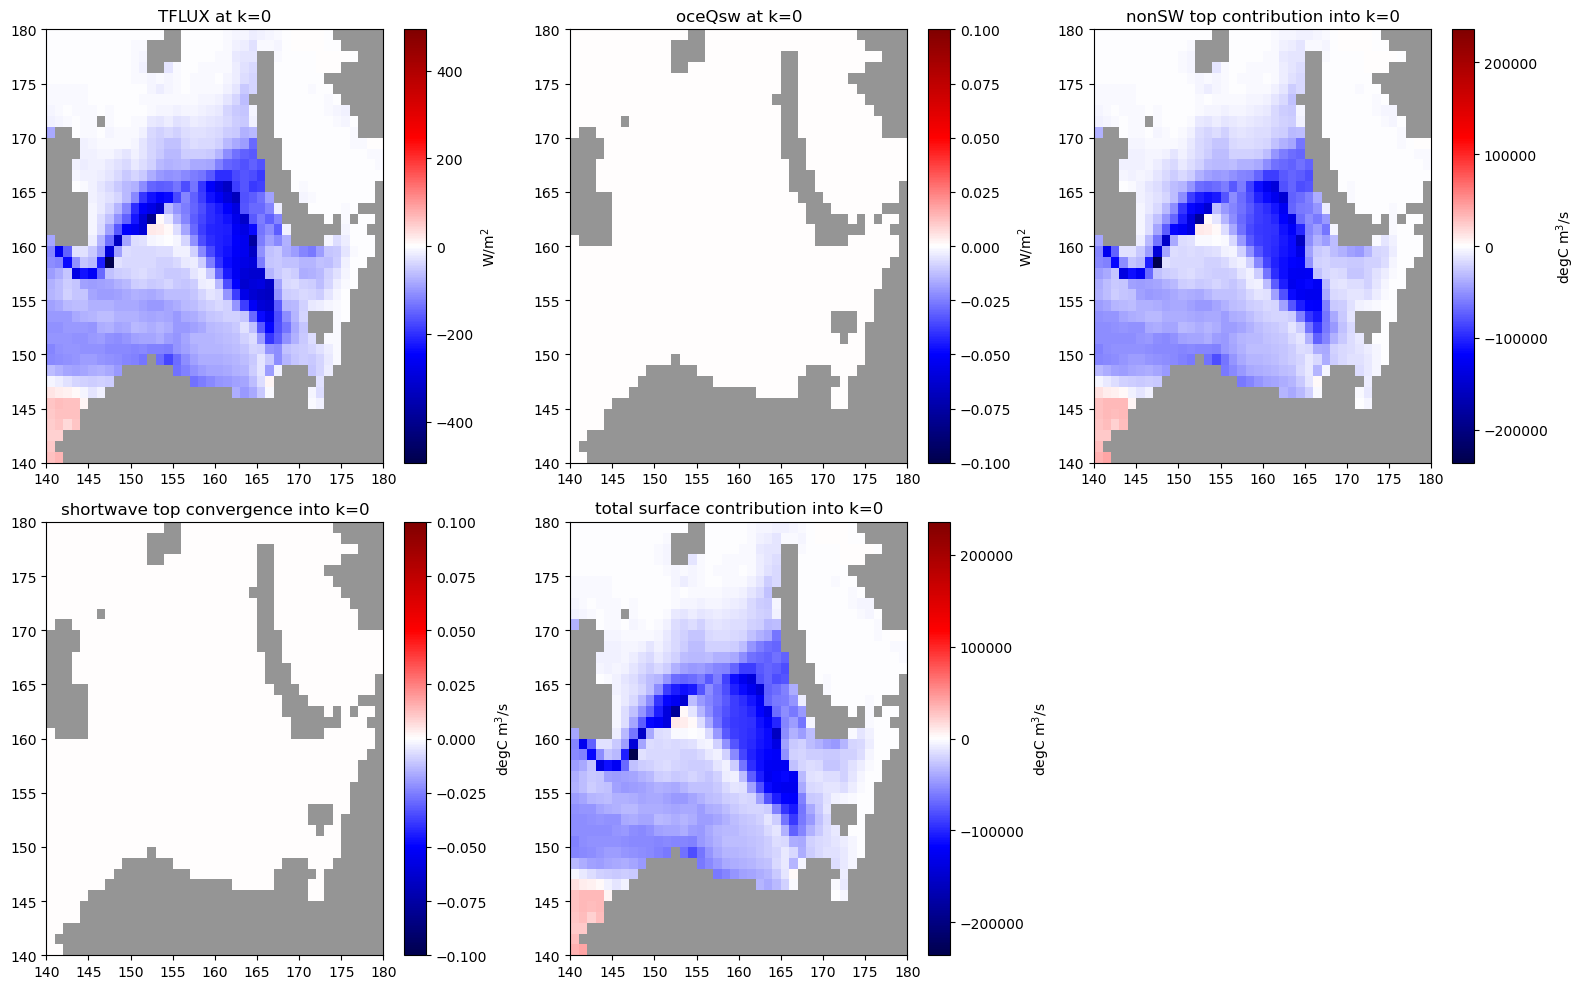

In [11]:
# plot each of the terms here and the original flux

fig = plt.figure(figsize=(16, 10))

# -------------------------------
# 1) total TFLUX
# -------------------------------
ax = plt.subplot(231)
vlev = np.nanmax(np.abs(TFLUX * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(TFLUX, nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="W/m$^2$")
ax.set_title("TFLUX at k=0")

# -------------------------------
# 2) surface shortwave input
# -------------------------------
ax = plt.subplot(232)
vlev = np.nanmax(np.abs(oceQsw * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(oceQsw, nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="W/m$^2$")
ax.set_title("oceQsw at k=0")

# -------------------------------
# 3) non-shortwave top contribution
# -------------------------------
ax = plt.subplot(233)
vlev = np.nanmax(np.abs(Ft_nonSW_top[0] * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(Ft_nonSW_top[0], nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="degC m$^3$/s")
ax.set_title("nonSW top contribution into k=0")

# -------------------------------
# 4) shortwave top-entry contribution
# -------------------------------
ax = plt.subplot(234)
vlev = np.nanmax(np.abs(Ft_Qsw_top[0] * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(Ft_Qsw_top[0], nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="degC m$^3$/s")
ax.set_title("shortwave top convergence into k=0")

# -------------------------------
# 6) total reconstructed surface contribution
# -------------------------------
ax = plt.subplot(235)
vlev = np.nanmax(np.abs(Ft_surf[0] * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(Ft_surf[0], nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="degC m$^3$/s")
ax.set_title("total surface contribution into k=0")

plt.tight_layout()
plt.show()

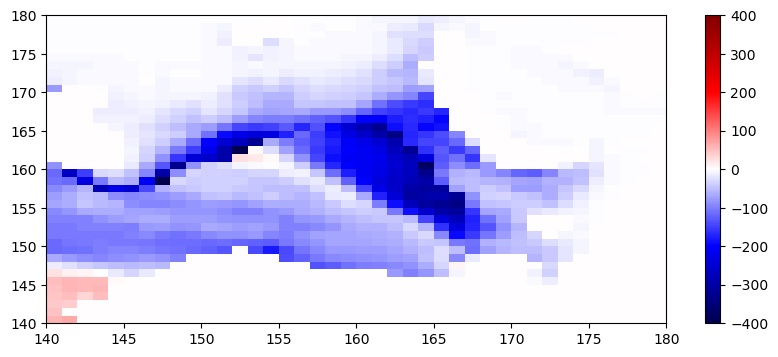

In [17]:
plt.pcolormesh(get_aste_tracer(oceQnet,nfx,nfy)[0],cmap='seismic',vmin=-400,vmax=400)
plt.xlim(140,180)
plt.ylim(140,180)
plt.colorbar()

## Same for the salt budget

In [12]:
# read fluxes
# load the surface salt terms
file_name = 'budg2d_zflux_set1'
meta_budg2d_zflux_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg2d_zflux_set1["fldList"])
rec_oceSPflx = np.where(fldlist == "oceSPflx")[0][0]
rec_SFLUX    = np.where(fldlist == "SFLUX")[0][0]
oceSPflx, its, meta = rdmds(os.path.join(dirdiags, file_name), t2, returnmeta=True, rec=rec_oceSPflx)
SFLUX,    its, meta = rdmds(os.path.join(dirdiags, file_name), t2, returnmeta=True, rec=rec_SFLUX)
oceSPflx = oceSPflx.reshape(ny, nx)
SFLUX    = SFLUX.reshape(ny, nx)

# read relax and salt mass
file_name = "budg2d_zflux_set2"
meta_budg2d_zflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg2d_zflux_set2["fldList"])
print(fldlist)
varnames = np.array(["oceSflux","WSLTMASS","SRELAX"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    if len(irec[0]) > 0:
        recs = np.append(recs, irec[0][0])
oceSflux,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
WSLTMASS,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
oceSflux = oceSflux.reshape(ny,nx)
WSLTMASS = WSLTMASS.reshape(ny,nx)

['WTHMASS' 'WSLTMASS' 'oceSflux' 'oceQnet' 'SIatmQnt' 'SIaaflux'
 'SIsnPrcp' 'SIacSubl']


In [13]:
# can we break this SFLUX more?

# files that have been defined in the salt forcing for the miniaste
# oceSPflx
# oceSPtnd


In [14]:
file_name = "budg3d_kpptend_set1"

meta = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta["fldList"])

rec_oceSPtnd = np.where(fldlist == "oceSPtnd")[0][0]

oceSPtnd, its, meta = rdmds(
    os.path.join(dirdiags, file_name),
    t2,
    returnmeta=True,
    rec=rec_oceSPtnd
)
oceSPtnd = oceSPtnd.reshape(nz, ny, nx)

RAC3 = np.broadcast_to(RAC[None, :, :], (nz, ny, nx))

rho = myparms["rhoconst"]

# ============================================================
# 1. Fluxes: g/s
# ============================================================

# Redistributed shortwave / penetrative salt flux at top face of each cell
flux_sp_top = (
    mk3D_mod(oceSPflx, oceSPtnd) - np.cumsum(oceSPtnd, axis=0)
) * RAC3

# Corresponding bottom-face flux for each cell
# Equivalent to: flux_sp_bot[k] = -flux_sp_top[k+1]
flux_sp_bot = np.zeros_like(flux_sp_top)
flux_sp_bot[:-1] = -flux_sp_top[1:]

# Vertical convergence of penetrative salt flux
# zconv_sp[k] = flux_sp_top[k] - flux_sp_top[k+1]
zconv_sp = flux_sp_top + flux_sp_bot


# Surface boundary flux: only exists at top of water column
flux_sflx_top = np.zeros_like(flux_sp_top)
flux_sflx_top[0] = SFLUX * RAC

flux_sflx_bot = np.zeros_like(flux_sflx_top)

zconv_sflx = flux_sflx_top - flux_sflx_bot


# Total top-face flux
flux_top = flux_sp_top.copy()
flux_top[0] += SFLUX * RAC

# Total bottom-face flux
flux_bot = np.zeros_like(flux_top)
flux_bot[:-1] = flux_top[1:]

# Total vertical convergence
zconv_total = flux_top - flux_bot


# ============================================================
# 2. Convert from g/s to PSU m^3/s
# ============================================================

tend_sp = zconv_sp / rho
tend_sflx = zconv_sflx / rho
tend_total = zconv_total / rho


# Optional: preserve old behavior of forcing bottom layer contribution to zero
# tend_sp[-1] = 0.0
# tend_total[-1] = 0.0


# ============================================================
# 3. Store separated fluxes, convergences, and tendencies
# ============================================================

fluxS3D = {}

fluxS3D["sp_top"] = flux_sp_top
fluxS3D["sp_bot"] = flux_sp_bot
fluxS3D["sflx_top"] = flux_sflx_top
fluxS3D["sflx_bot"] = flux_sflx_bot
fluxS3D["total_top"] = flux_top
fluxS3D["total_bot"] = flux_bot


zconvS3D = {}

zconvS3D["sp"] = zconv_sp
zconvS3D["sflx"] = zconv_sflx
zconvS3D["total"] = zconv_total


termsS3D = {}

termsS3D["sp"] = tend_sp
termsS3D["sflx"] = tend_sflx
termsS3D["surf"] = tend_total

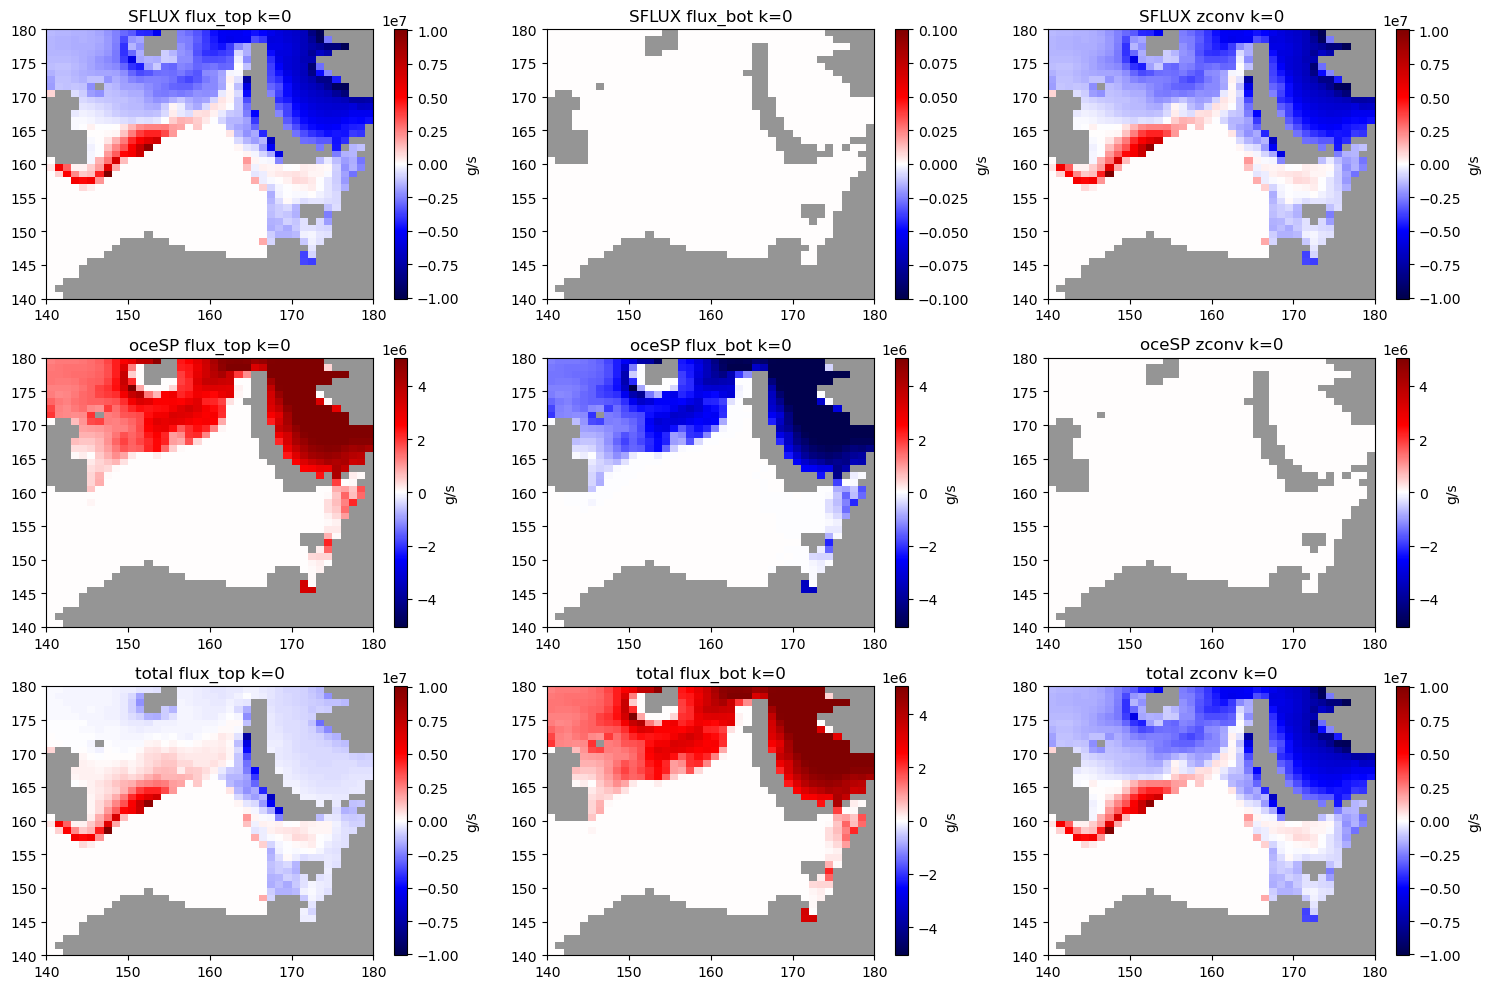

In [16]:
# plot separated salt fluxes: top and bottom faces

fig = plt.figure(figsize=(15, 10))

def plot_panel(ax, fld, k, title, units="g/s"):
    vlev = np.nanmax(np.abs(fld * mymsk))
    cb = ax.pcolormesh(
        get_aste_tracer(fld, nfx, nfy)[k],
        cmap="seismic", vmin=-vlev, vmax=vlev
    )
    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap="Greys", vmin=0, vmax=2
    )
    ax.set_xlim(140, 180)
    ax.set_ylim(140, 180)
    plt.colorbar(cb, ax=ax, label=units)
    ax.set_title(title)


# ------------------------------------------------------------
# SFLUX fluxes
# ------------------------------------------------------------

ax = plt.subplot(331)
plot_panel(
    ax,
    fluxS3D["sflx_top"],
    0,
    "SFLUX flux_top k=0"
)

ax = plt.subplot(332)
plot_panel(
    ax,
    fluxS3D["sflx_bot"],
    0,
    "SFLUX flux_bot k=0"
)

ax = plt.subplot(333)
plot_panel(
    ax,
    zconvS3D["sflx"],
    0,
    "SFLUX zconv k=0"
)


# ------------------------------------------------------------
# oceSPflx / oceSPtnd redistributed fluxes
# ------------------------------------------------------------

ax = plt.subplot(334)
plot_panel(
    ax,
    fluxS3D["sp_top"],
    0,
    "oceSP flux_top k=0"
)

ax = plt.subplot(335)
plot_panel(
    ax,
    fluxS3D["sp_bot"],
    0,
    "oceSP flux_bot k=0"
)

ax = plt.subplot(336)
plot_panel(
    ax,
    zconvS3D["sp"],
    0,
    "oceSP zconv k=0"
)


# ------------------------------------------------------------
# Total fluxes
# ------------------------------------------------------------

ax = plt.subplot(337)
plot_panel(
    ax,
    fluxS3D["total_top"],
    0,
    "total flux_top k=0"
)

ax = plt.subplot(338)
plot_panel(
    ax,
    fluxS3D["total_bot"],
    0,
    "total flux_bot k=0"
)

ax = plt.subplot(339)
plot_panel(
    ax,
    zconvS3D["total"],
    0,
    "total zconv k=0"
)

plt.tight_layout()

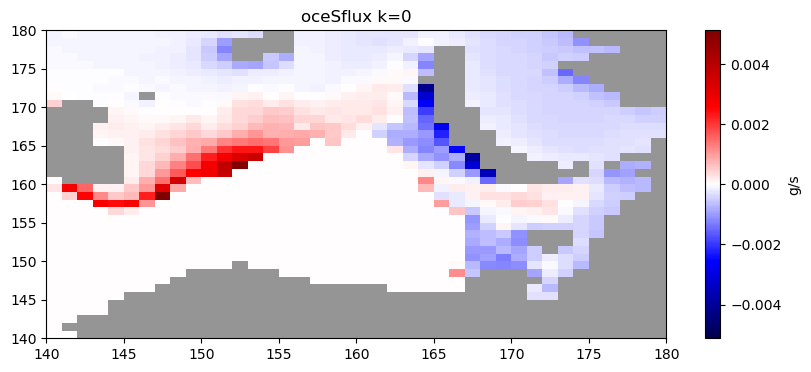

In [19]:
fig = plt.figure()

ax = plt.subplot(111)
plot_panel(
    ax,
    oceSflux,
    0,
    "oceSflux k=0"
)

## plot the breakdown of tflux

In [53]:
land_data = get_aste_tracer(landmsk,nfx,nfy)[0]

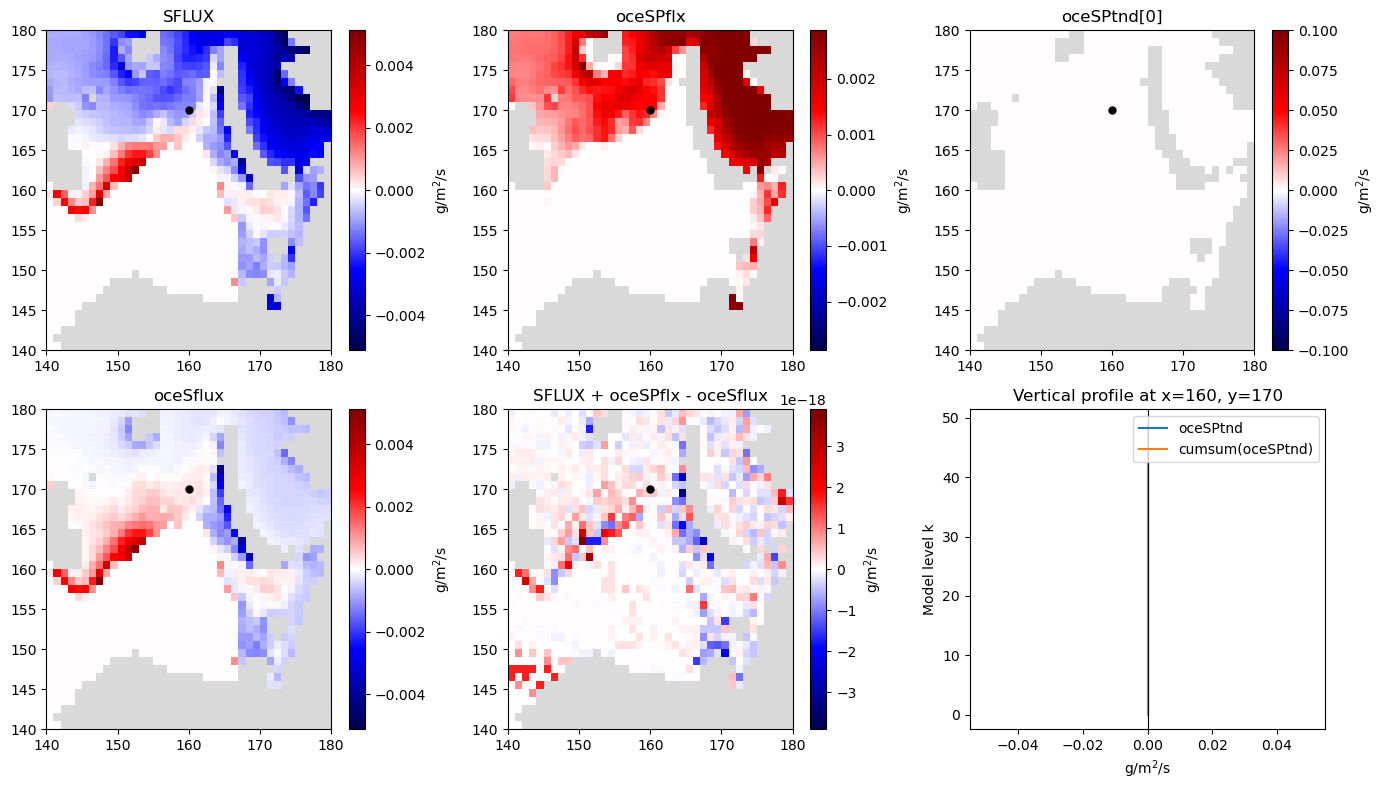

In [72]:
fig = plt.figure(figsize=(14,8))

xlim = (140,180)
ylim = (140,180)

# choose point/region for vertical profile
# use the center of the plotted region
ii0 = 160
jj0 = 170

ax = plt.subplot(231)
vlev = np.nanmax(np.abs(SFLUX*mymsk))
cb = ax.pcolormesh(get_aste_tracer(SFLUX,nfx,nfy)[0], cmap='seismic',
                   vmin=-vlev, vmax=vlev)
ax.pcolormesh(land_data, cmap="Greys", vmin=0, vmax=4)
ax.plot(ii0, jj0, 'ko', markersize=5)
plt.colorbar(cb, label="g/m$^2$/s")
ax.set_title("SFLUX")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax = plt.subplot(232)
vlev = np.nanmax(np.abs(oceSPflx*mymsk))
cb = ax.pcolormesh(get_aste_tracer(oceSPflx,nfx,nfy)[0], cmap='seismic',
                   vmin=-vlev, vmax=vlev)
ax.pcolormesh(land_data, cmap="Greys", vmin=0, vmax=4)
ax.plot(ii0, jj0, 'ko', markersize=5)
plt.colorbar(cb, label="g/m$^2$/s")
ax.set_title("oceSPflx")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax = plt.subplot(233)
vlev = np.nanmax(np.abs(oceSPtnd[0]*mymsk))
cb = ax.pcolormesh(get_aste_tracer(oceSPtnd[0],nfx,nfy)[0], cmap='seismic',
                   vmin=-vlev, vmax=vlev)
ax.pcolormesh(land_data, cmap="Greys", vmin=0, vmax=4)
ax.plot(ii0, jj0, 'ko', markersize=5)
plt.colorbar(cb, label="g/m$^2$/s")
ax.set_title("oceSPtnd[0]")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax = plt.subplot(234)
vlev = np.nanmax(np.abs(oceSflux*mymsk))
cb = ax.pcolormesh(get_aste_tracer(oceSflux,nfx,nfy)[0], cmap='seismic',
                   vmin=-vlev, vmax=vlev)
ax.pcolormesh(land_data, cmap="Greys", vmin=0, vmax=4)
ax.plot(ii0, jj0, 'ko', markersize=5)
plt.colorbar(cb, label="g/m$^2$/s")
ax.set_title("oceSflux")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax = plt.subplot(235)
S_resid_top = SFLUX + oceSPflx - oceSflux
vlev = np.nanmax(np.abs(S_resid_top*mymsk))
cb = ax.pcolormesh(get_aste_tracer(S_resid_top,nfx,nfy)[0], cmap='seismic',
                   vmin=-vlev, vmax=vlev)
ax.pcolormesh(land_data, cmap="Greys", vmin=0, vmax=4)
ax.plot(ii0, jj0, 'ko', markersize=5)
plt.colorbar(cb, label="g/m$^2$/s")
ax.set_title("SFLUX + oceSPflx - oceSflux")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# ------------------------------------------------------
# Vertical profile: cumulative sum of oceSPtnd
# ------------------------------------------------------
ax = plt.subplot(236)

# Extract ASTE-shaped column from transformed oceSPtnd
oceSPtnd_aste = get_aste_tracer(oceSPtnd, nfx, nfy)  # expected shape: nz, ny, nx
sp_tnd_col = oceSPtnd_aste[:, jj0, ii0]

# cumulative deposited salt from surface downward
sp_tnd_cumsum = np.nancumsum(sp_tnd_col)

# use depth coordinate if available; otherwise layer index
if 'Z' in globals():
    zcoord = Z
    ylabel = "Depth [m]"
elif 'RC' in globals():
    zcoord = RC.squeeze()
    ylabel = "Depth [m]"
else:
    zcoord = np.arange(len(sp_tnd_col))
    ylabel = "Model level k"

ax.plot(sp_tnd_col, zcoord, label="oceSPtnd")
ax.plot(sp_tnd_cumsum, zcoord, label="cumsum(oceSPtnd)")

ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("g/m$^2$/s")
ax.set_ylabel(ylabel)
ax.set_title(f"Vertical profile at x={ii0}, y={jj0}")
ax.legend()

# put surface at top if using depth negative/downward
if np.nanmean(np.diff(zcoord)) < 0:
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

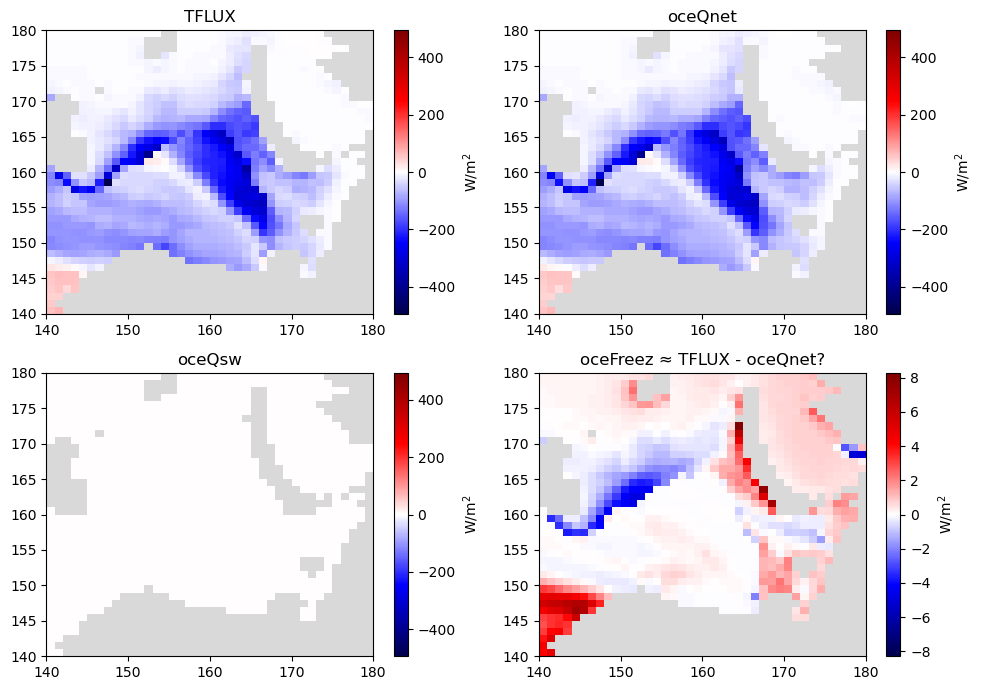

In [74]:
xlim = (140, 180)
ylim = (140, 180)

def plot_aste_panel(ax, var, title, units="W/m$^2$", vlev=None):
    plot_var = get_aste_tracer(var, nfx, nfy)[0]
    
    if vlev is None:
        vlev = np.nanmax(np.abs(var * mymsk))
    
    cb = ax.pcolormesh(
        plot_var,
        cmap="seismic",
        vmin=-vlev,
        vmax=vlev
    )
    ax.pcolormesh(land_data, cmap="Greys", vmin=0, vmax=4)
    plt.colorbar(cb, ax=ax, label=units)
    ax.set_title(title)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    return cb


# ------------------------------------------------------------
# Expected diagnostic identity:
#
# TFLUX ≈ oceQnet + oceFreez + RFWF_heat_term
#
# If RFWF heat-content correction is small:
#
# oceFreez ≈ TFLUX - oceQnet
# ------------------------------------------------------------

oceFreez_est = TFLUX - oceQnet

# Common scale for main heat flux fields
main_fields = [
    TFLUX * mymsk,
    oceQnet * mymsk,
    oceQsw * mymsk
]

vlev_main = np.nanmax(np.abs(np.stack(main_fields)))

# Separate scale for oceFreez estimate
vlev_freez = np.nanmax(np.abs(oceFreez_est * mymsk))


fig = plt.figure(figsize=(10, 7))

ax = plt.subplot(221)
plot_aste_panel(ax, TFLUX, "TFLUX", vlev=vlev_main)

ax = plt.subplot(222)
plot_aste_panel(ax, oceQnet, "oceQnet", vlev=vlev_main)

ax = plt.subplot(223)
plot_aste_panel(ax, oceQsw, "oceQsw", vlev=vlev_main)

ax = plt.subplot(224)
plot_aste_panel(
    ax,
    oceFreez_est,
    "oceFreez ≈ TFLUX - oceQnet?",
    vlev=vlev_freez
)

plt.tight_layout()
plt.show()

In [55]:
# oceQnet
# SIatmQnt
# SIsnPrcp
# SIacSubl
# SIaaflux

(140.0, 180.0)

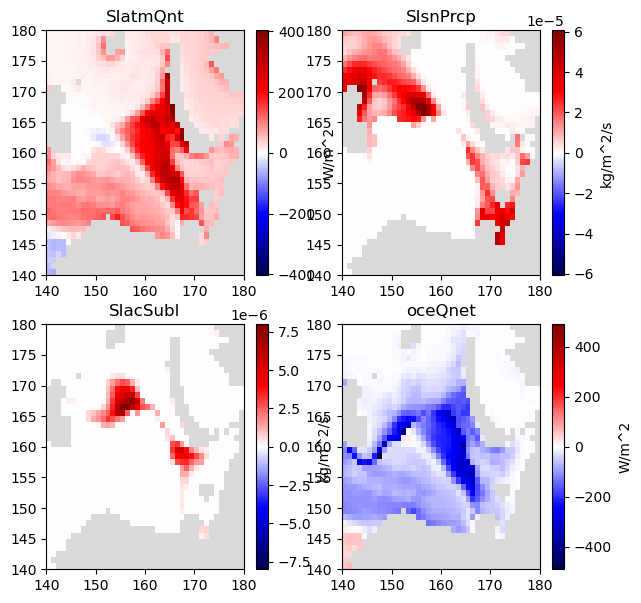

In [56]:

fig = plt.figure(figsize=(7,7))

ax = plt.subplot(221)
vlev = np.nanmax(np.abs(SIatmQnt*mymsk))
cb = ax.pcolormesh(get_aste_tracer(SIatmQnt,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="W/m^2")
ax.set_title("SIatmQnt")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

ax = plt.subplot(222)
vlev = np.nanmax(np.abs(SIsnPrcp*mymsk))
cb = ax.pcolormesh(get_aste_tracer(SIsnPrcp,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="kg/m^2/s")
ax.set_title("SIsnPrcp")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

ax = plt.subplot(223)
vlev = np.nanmax(np.abs(SIacSubl*mymsk))
cb = ax.pcolormesh(get_aste_tracer(SIacSubl,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="kg/m^2/s")
ax.set_title("SIacSubl")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

ax = plt.subplot(224)
vlev = np.nanmax(np.abs(oceQnet*mymsk))
cb = ax.pcolormesh(get_aste_tracer(oceQnet,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="W/m^2")
ax.set_title("oceQnet")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

(140.0, 180.0)

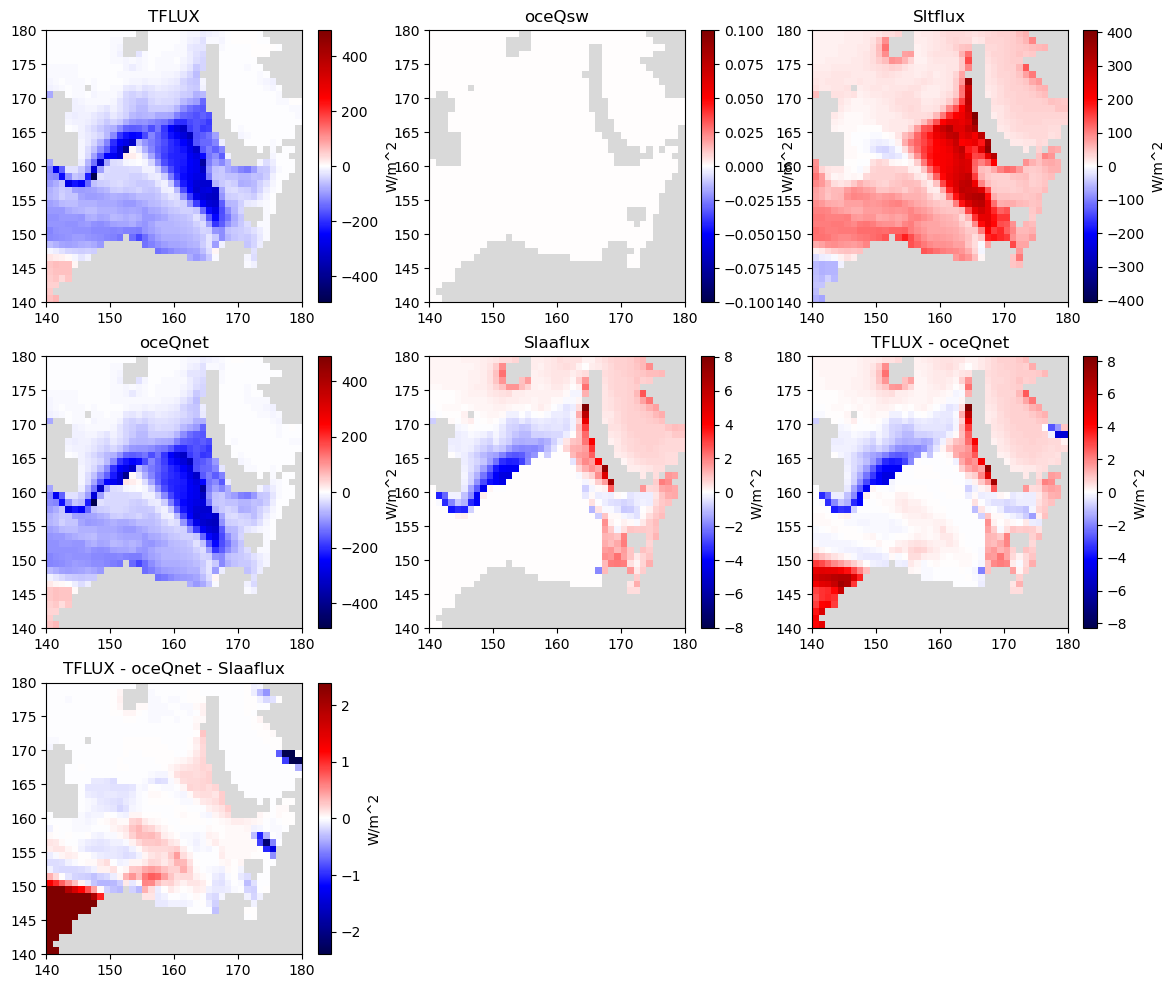

In [57]:
# do the breakdown for tflux

fig = plt.figure(figsize=(14,12))

ax = plt.subplot(331)
vlev = np.nanmax(np.abs(TFLUX*mymsk))
cb = ax.pcolormesh(get_aste_tracer(TFLUX,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="W/m^2")
ax.set_title("TFLUX")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

ax = plt.subplot(332)
vlev = np.nanmax(np.abs(oceQsw*mymsk))
cb = ax.pcolormesh(get_aste_tracer(oceQsw,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="W/m^2")
ax.set_title("oceQsw")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

ax = plt.subplot(333)
vlev = np.nanmax(np.abs(SItflux*mymsk))
cb = ax.pcolormesh(get_aste_tracer(SItflux,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="W/m^2")
ax.set_title("SItflux")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

ax = plt.subplot(334)
vlev = np.nanmax(np.abs(oceQnet*mymsk))
cb = ax.pcolormesh(get_aste_tracer(oceQnet,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="W/m^2")
ax.set_title("oceQnet")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

ax = plt.subplot(335)
vlev = np.nanmax(np.abs(SIaaflux*mymsk))
cb = ax.pcolormesh(get_aste_tracer(SIaaflux,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="W/m^2")
ax.set_title("SIaaflux")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

ax = plt.subplot(336)
T_resid_top = TFLUX - oceQnet
vlev = np.nanmax(np.abs(T_resid_top*mymsk))
cb = ax.pcolormesh(get_aste_tracer(T_resid_top,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="W/m^2")
ax.set_title("TFLUX - oceQnet")
ax.set_xlim(140,180)
ax.set_ylim(140,180)

ax = plt.subplot(337)
T_resid_top = TFLUX - oceQnet - SIaaflux
vlev = np.nanmax(np.abs(T_resid_top*mymsk))/3
cb = ax.pcolormesh(get_aste_tracer(T_resid_top,nfx,nfy)[0],cmap='seismic',vmin=-vlev,vmax=vlev)
ax.pcolormesh(land_data,cmap="Greys",vmin=0,vmax=4)
plt.colorbar(cb,label="W/m^2")
ax.set_title("TFLUX - oceQnet - SIaaflux")
ax.set_xlim(140,180)
ax.set_ylim(140,180)


In [58]:
oceFWflx

NameError: name 'oceFWflx' is not defined